## Setup Lingkungan dan Dataset MNIST

Kita akan menggunakan PyTorch sebagai framework dan dataset MNIST untuk tugas ini. Langkah pertama adalah mengimpor library yang diperlukan, menentukan perangkat (GPU jika tersedia), dan menyiapkan data.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision # Import torchvision secara eksplisit
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time
import os

# Tentukan perangkat (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan perangkat: {device}")

Menggunakan perangkat: cpu


### Transformasi Data dan Loading Dataset

Kita akan mendefinisikan transformasi untuk data gambar (normalisasi) dan kemudian mengunduh dataset MNIST. Dataset akan dibagi menjadi set pelatihan, validasi, dan pengujian.

In [ ]:
# Transformasi data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Unduh dan muat dataset MNIST
# Pastikan untuk mengatur download=True agar dataset diunduh jika belum ada
train_val_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Bagi dataset pelatihan menjadi set pelatihan dan validasi
train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

print(f"Ukuran dataset pelatihan: {len(train_dataset)}")
print(f"Ukuran dataset validasi: {len(val_dataset)}")
print(f"Ukuran dataset pengujian: {len(test_dataset)}")

# Buat DataLoaders
batch_size = 64 # Anda bisa menyesuaikan batch_size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Kelas-kelas di MNIST (angka 0-9)
classes = [str(i) for i in range(10)]

Ukuran dataset pelatihan: 48000
Ukuran dataset validasi: 12000
Ukuran dataset pengujian: 10000


### Visualisasi Contoh Gambar

Mari kita lihat beberapa contoh gambar dari dataset untuk memastikan data telah dimuat dengan benar.

Contoh gambar dari dataset MNIST:


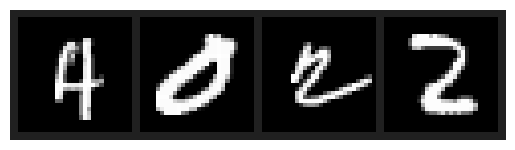

4     0     2     2    


In [ ]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()

    # Transpose dari (C, H, W) menjadi (H, W, C)
    # torchvision.utils.make_grid akan membuat gambar grayscale menjadi 3 channel (replikasi)
    npimg = np.transpose(npimg, (1, 2, 0))

    # Untuk gambar grayscale yang direplikasi 3 channel, kita hanya perlu satu channel untuk ditampilkan
    if npimg.shape[2] == 3: # Cek jika ada 3 channel
        npimg = npimg[:, :, 0] # Ambil channel pertama

    plt.imshow(npimg, cmap='gray') # Sekarang npimg seharusnya berformat (H, W)
    plt.axis('off')
    plt.show()

# Dapatkan beberapa gambar pelatihan acak
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Tampilkan gambar
print('Contoh gambar dari dataset MNIST:')
imshow(torchvision.utils.make_grid(images[:4]))
# Cetak label
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

## B.2 — Implementasi Model

Kita akan mendefinisikan dua model CNN: Model A (custom CNN sederhana) dan Model B (CNN dengan residual connection). Kedua model akan dilatih pada dataset MNIST.

### Model A — Custom CNN Sederhana

Model ini akan terdiri dari minimal 3 blok Conv-ReLU-Pooling, diikuti oleh fully connected layer dan output softmax (yang akan ditangani oleh `CrossEntropyLoss` secara implisit).

In [ ]:
class ModelA(nn.Module):
    def __init__(self):
        super(ModelA, self).__init__()
        # MNIST images are 1 channel (grayscale), 28x28
        # Output size after Conv2d formula: (W - F + 2P) / S + 1
        # Output size after MaxPool2d formula: W / S

        self.cnn_layers = nn.Sequential(
            # Block 1: Conv -> ReLU -> MaxPool
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), # Output: 32x28x28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 32x14x14

            # Block 2: Conv -> ReLU -> MaxPool
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # Output: 64x14x14
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 64x7x7

            # Block 3: Conv -> ReLU -> MaxPool
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), # Output: 128x7x7
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Output: 128x3x3 (karena 7/2=3.5, dibulatkan ke bawah)
        )

        # Hitung ukuran input untuk fully connected layer
        # MNIST input: 1x28x28. Setelah cnn_layers: 128 * 3 * 3 = 1152
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 3 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, len(classes)) # Output 10 kelas untuk MNIST
        )

    def forward(self, x):
        x = self.cnn_layers(x)
        x = x.view(x.size(0), -1) # Flatten the output for FC layers
        x = self.fc_layers(x)
        return x

### Model B — CNN dengan Residual Connection

Kita akan membangun Model B menggunakan blok residual sederhana. Setiap blok residual akan memiliki dua lapisan konvolusi dengan skip connection.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(residual) # Tambahkan skip connection
        out = self.relu(out)
        return out


class ModelB(nn.Module):
    def __init__(self, num_residual_blocks=3):
        super(ModelB, self).__init__()
        self.in_channels = 16 # Saluran awal

        self.conv_init = nn.Sequential(
            nn.Conv2d(1, self.in_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(self.in_channels),
            nn.ReLU(inplace=True)
        )

        self.layer1 = self._make_layer(ResidualBlock, 16, num_residual_blocks, stride=1)
        self.layer2 = self._make_layer(ResidualBlock, 32, num_residual_blocks, stride=2) # Mengurangi ukuran spasial
        self.layer3 = self._make_layer(ResidualBlock, 64, num_residual_blocks, stride=2) # Mengurangi ukuran spasial

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, len(classes))

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride_val in strides:
            layers.append(block(self.in_channels, out_channels, stride_val))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv_init(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

### Fungsi Pembantu: Menghitung Jumlah Parameter

Kita akan menggunakan fungsi ini untuk membandingkan kompleksitas kedua model.

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Inisialisasi model dan hitung parameter
model_a = ModelA().to(device)
model_b = ModelB().to(device)

print(f"Jumlah parameter Model A: {count_parameters(model_a)}")
print(f"Jumlah parameter Model B: {count_parameters(model_b)}")

Jumlah parameter Model A: 688138
Jumlah parameter Model B: 272186


### Fungsi Pelatihan dan Evaluasi

Kita akan membuat fungsi pembantu untuk melatih dan mengevaluasi model.

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    model.train() # Set model ke mode pelatihan
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    start_time = time.time()

    for epoch in range(num_epochs):
        # Pelatihan
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_accuracy = 100 * correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_accuracy)

        # Validasi
        model.eval() # Set model ke mode evaluasi
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs_val, labels_val in val_loader:
                inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
                outputs_val = model(inputs_val)
                loss_val = criterion(outputs_val, labels_val)

                val_loss += loss_val.item()
                _, predicted_val = torch.max(outputs_val.data, 1)
                total_val += labels_val.size(0)
                correct_val += (predicted_val == labels_val).sum().item()

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_accuracy = 100 * correct_val / total_val
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}, ' +
              f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}%, ' +
              f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.2f}%')

        model.train() # Kembali ke mode pelatihan

    end_time = time.time()
    total_training_time = end_time - start_time
    print(f'Pelatihan selesai dalam {total_training_time:.2f} detik')

    return train_losses, val_losses, train_accuracies, val_accuracies, total_training_time

def evaluate_model(model, data_loader, criterion):
    model.eval() # Set model ke mode evaluasi
    test_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = test_loss / len(data_loader)
    accuracy = 100 * correct / total
    print(f'Loss: {avg_loss:.4f}, Akurasi: {accuracy:.2f}%')
    return avg_loss, accuracy, all_predictions, all_labels

### Hyperparameter dan Persiapan Pelatihan

Kita akan menggunakan _hyperparameter_ yang sama untuk kedua model untuk memastikan perbandingan yang adil.

In [ ]:
# Hyperparameter
learning_rate = 0.001
num_epochs = 10

# Fungsi Loss dan Optimizer
criterion = nn.CrossEntropyLoss()

print("Memulai pelatihan Model A...")
optimizer_a = optim.Adam(model_a.parameters(), lr=learning_rate)
train_losses_a, val_losses_a, train_accuracies_a, val_accuracies_a, time_a = train_model(
    model_a, train_loader, val_loader, criterion, optimizer_a, num_epochs=num_epochs
)

print("\nMemulai pelatihan Model B...")
optimizer_b = optim.Adam(model_b.parameters(), lr=learning_rate)
train_losses_b, val_losses_b, train_accuracies_b, val_accuracies_b, time_b = train_model(
    model_b, train_loader, val_loader, criterion, optimizer_b, num_epochs=num_epochs
)

Memulai pelatihan Model A...
Epoch 1/10, Train Loss: 0.1515, Train Acc: 95.16%, Val Loss: 0.0543, Val Acc: 98.39%
Epoch 2/10, Train Loss: 0.0449, Train Acc: 98.59%, Val Loss: 0.0344, Val Acc: 99.01%
Epoch 3/10, Train Loss: 0.0311, Train Acc: 99.09%, Val Loss: 0.0401, Val Acc: 98.84%
Epoch 4/10, Train Loss: 0.0248, Train Acc: 99.20%, Val Loss: 0.0299, Val Acc: 99.06%
Epoch 5/10, Train Loss: 0.0205, Train Acc: 99.34%, Val Loss: 0.0370, Val Acc: 98.95%
Epoch 6/10, Train Loss: 0.0170, Train Acc: 99.44%, Val Loss: 0.0299, Val Acc: 99.05%
Epoch 7/10, Train Loss: 0.0125, Train Acc: 99.59%, Val Loss: 0.0372, Val Acc: 99.05%
Epoch 8/10, Train Loss: 0.0134, Train Acc: 99.58%, Val Loss: 0.0417, Val Acc: 98.86%
Epoch 9/10, Train Loss: 0.0117, Train Acc: 99.64%, Val Loss: 0.0291, Val Acc: 99.29%
Epoch 10/10, Train Loss: 0.0093, Train Acc: 99.71%, Val Loss: 0.0282, Val Acc: 99.24%
Pelatihan selesai dalam 1203.31 detik

Memulai pelatihan Model B...
Epoch 1/10, Train Loss: 0.1575, Train Acc: 95.55%, V

## B.3 — Eksperimen dan Evaluasi

Kita akan menganalisis kinerja kedua model berdasarkan metrik pelatihan dan validasi.

### Visualisasi _Training Loss_ dan _Accuracy_ (_Model A vs Model B_)

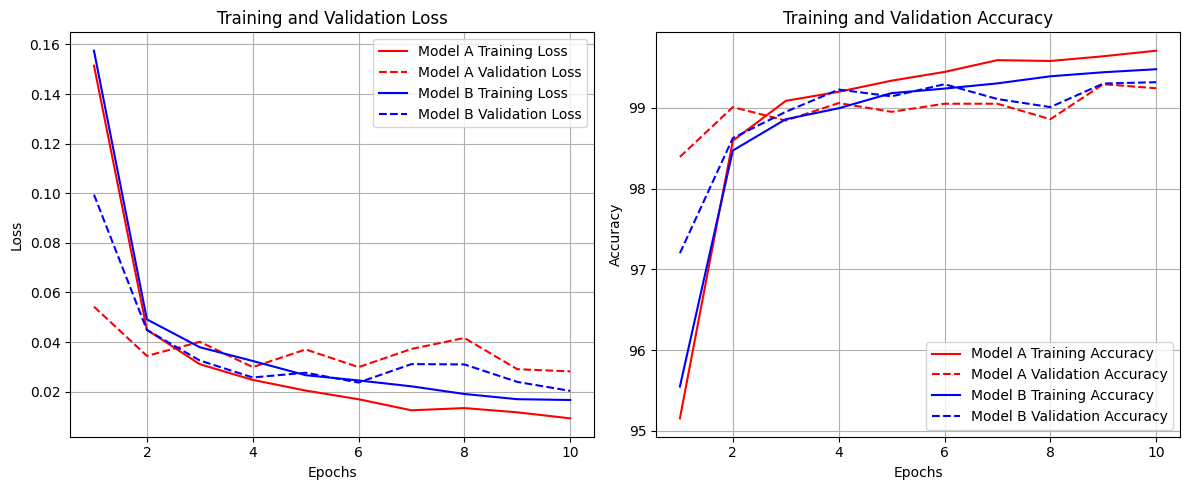

In [ ]:
import matplotlib.pyplot as plt # Import pyplot

# Hyperparameter (redifined for plotting robustness)
num_epochs = 10

# Buat rentang epoch untuk sumbu x
epochs = range(1, num_epochs + 1)

# Plot Training & Validation Loss
fig1 = plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_a, 'r', label='Model A Training Loss')
plt.plot(epochs, val_losses_a, 'r--', label='Model A Validation Loss')
plt.plot(epochs, train_losses_b, 'b', label='Model B Training Loss')
plt.plot(epochs, val_losses_b, 'b--', label='Model B Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies_a, 'r', label='Model A Training Accuracy')
plt.plot(epochs, val_accuracies_a, 'r--', label='Model A Validation Accuracy')
plt.plot(epochs, train_accuracies_b, 'b', label='Model B Training Accuracy')
plt.plot(epochs, val_accuracies_b, 'b--', label='Model B Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Akurasi pada Set Pengujian dan Waktu Pelatihan Total

Sekarang kita akan mengevaluasi kinerja akhir kedua model pada set data pengujian yang belum pernah terlihat dan menampilkan total waktu yang dibutuhkan untuk pelatihan.

In [ ]:
# Evaluasi Model A pada test set
print("\nEvaluasi Model A pada Test Set:")
test_loss_a, test_accuracy_a, predictions_a, labels_a = evaluate_model(
    model_a, test_loader, criterion
)

# Evaluasi Model B pada test set
print("\nEvaluasi Model B pada Test Set:")
test_loss_b, test_accuracy_b, predictions_b, labels_b = evaluate_model(
    model_b, test_loader, criterion
)

print(f"\nTotal waktu pelatihan Model A: {time_a:.2f} detik")
print(f"Total waktu pelatihan Model B: {time_b:.2f} detik")


Evaluasi Model A pada Test Set:
Loss: 0.0315, Akurasi: 99.22%

Evaluasi Model B pada Test Set:
Loss: 0.0213, Akurasi: 99.37%

Total waktu pelatihan Model A: 1203.31 detik
Total waktu pelatihan Model B: 3760.73 detik


### Confusion Matrix

Kita akan memvisualisasikan _confusion matrix_ untuk kedua model untuk melihat bagaimana kinerja masing-masing model dalam mengklasifikasikan setiap kelas (digit).

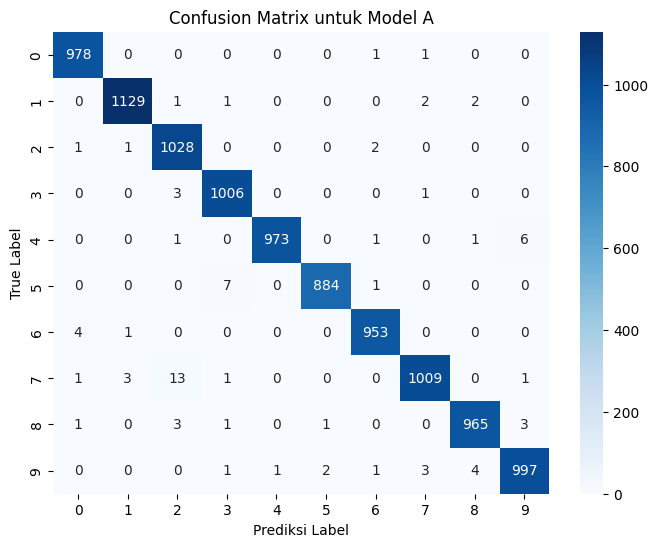

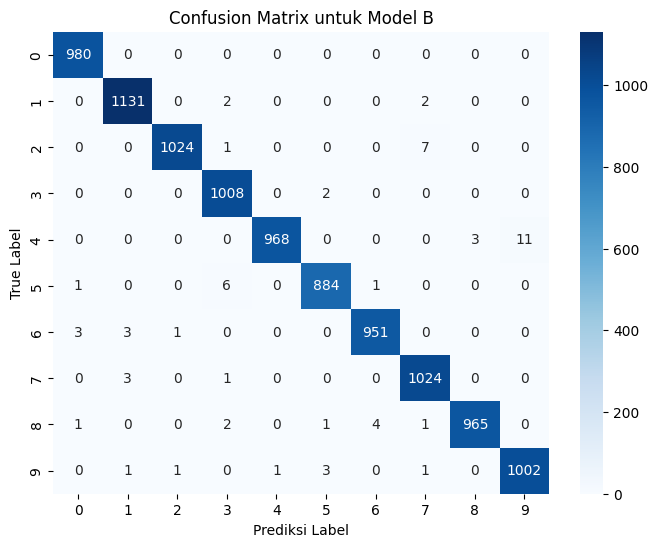

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Fungsi untuk menggambar Confusion Matrix
def plot_confusion_matrix(labels, predictions, classes, model_name):
    cm = confusion_matrix(labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix untuk {model_name}')
    plt.xlabel('Prediksi Label')
    plt.ylabel('True Label')
    plt.show()

# Confusion Matrix untuk Model A
plot_confusion_matrix(labels_a, predictions_a, classes, 'Model A')

# Confusion Matrix untuk Model B
plot_confusion_matrix(labels_b, predictions_b, classes, 'Model B')

## B.4 — Studi Ablasi

Sekarang kita akan melanjutkan ke bagian B.4: Studi Ablasi. Anda perlu memilih salah satu eksperimen ablasi berikut:
1.  **Pengaruh _Dropout_**: Menambahkan atau mengubah tingkat _dropout_ pada salah satu model.
2.  **Perbandingan _Pooling_**: Mengganti jenis _pooling_ (misalnya, _MaxPool_ ke _AvgPool_) pada salah satu model.
3.  **Variasi Kedalaman Model B**: Mengubah jumlah blok residual pada Model B.

Eksperimen mana yang ingin Anda lakukan?

### Studi Ablasi: Perbandingan Pooling (MaxPool vs AvgPool)

Dalam eksperimen ini, kita akan memodifikasi `ModelA` untuk menggunakan Average Pooling (`AvgPool2d`) sebagai ganti Max Pooling (`MaxPool2d`) untuk mengamati dampaknya pada kinerja model.

In [ ]:
class ModelA_AvgPool(nn.Module):
    def __init__(self):
        super(ModelA_AvgPool, self).__init__()
        self.cnn_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), # Output: 32x28x28
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2), # Ganti MaxPool2d dengan AvgPool2d. Output: 32x14x14

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # Output: 64x14x14
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2), # Ganti MaxPool2d dengan AvgPool2d. Output: 64x7x7

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), # Output: 128x7x7
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2) # Ganti MaxPool2d dengan AvgPool2d. Output: 128x3x3
        )

        # Hitung ukuran input untuk fully connected layer
        # MNIST input: 1x28x28. Setelah cnn_layers: 128 * 3 * 3 = 1152
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 3 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, len(classes))
        )

    def forward(self, x):
        x = self.cnn_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

print('ModelA_AvgPool class defined.')

ModelA_AvgPool class defined.


Sekarang, kita akan menginisialisasi `ModelA_AvgPool`, melatihnya, dan mengevaluasinya.

In [ ]:
# Inisialisasi Model A dengan Average Pooling
model_a_avgpool = ModelA_AvgPool().to(device)

print(f"Jumlah parameter Model A (AvgPool): {count_parameters(model_a_avgpool)}")

# Fungsi Loss dan Optimizer
criterion_avgpool = nn.CrossEntropyLoss()
optimizer_a_avgpool = optim.Adam(model_a_avgpool.parameters(), lr=learning_rate)

print("\nMemulai pelatihan Model A dengan Average Pooling...")
train_losses_a_avgpool, val_losses_a_avgpool, train_accuracies_a_avgpool, val_accuracies_a_avgpool, time_a_avgpool = train_model(
    model_a_avgpool, train_loader, val_loader, criterion_avgpool, optimizer_a_avgpool, num_epochs=num_epochs
)

# Evaluasi Model A (AvgPool) pada test set
print("\nEvaluasi Model A (AvgPool) pada Test Set:")
test_loss_a_avgpool, test_accuracy_a_avgpool, predictions_a_avgpool, labels_a_avgpool = evaluate_model(
    model_a_avgpool, test_loader, criterion_avgpool
)

print(f"\nTotal waktu pelatihan Model A (AvgPool): {time_a_avgpool:.2f} detik")

Jumlah parameter Model A (AvgPool): 688138

Memulai pelatihan Model A dengan Average Pooling...
Epoch 1/10, Train Loss: 0.2124, Train Acc: 93.52%, Val Loss: 0.0903, Val Acc: 97.13%
Epoch 2/10, Train Loss: 0.0641, Train Acc: 98.05%, Val Loss: 0.0443, Val Acc: 98.69%
Epoch 3/10, Train Loss: 0.0418, Train Acc: 98.68%, Val Loss: 0.0504, Val Acc: 98.52%
Epoch 4/10, Train Loss: 0.0333, Train Acc: 98.94%, Val Loss: 0.0396, Val Acc: 98.81%
Epoch 5/10, Train Loss: 0.0269, Train Acc: 99.11%, Val Loss: 0.0334, Val Acc: 98.91%
Epoch 6/10, Train Loss: 0.0228, Train Acc: 99.29%, Val Loss: 0.0297, Val Acc: 99.08%
Epoch 7/10, Train Loss: 0.0197, Train Acc: 99.35%, Val Loss: 0.0312, Val Acc: 99.05%
Epoch 8/10, Train Loss: 0.0158, Train Acc: 99.47%, Val Loss: 0.0433, Val Acc: 98.85%
Epoch 9/10, Train Loss: 0.0136, Train Acc: 99.54%, Val Loss: 0.0301, Val Acc: 99.13%
Epoch 10/10, Train Loss: 0.0131, Train Acc: 99.58%, Val Loss: 0.0305, Val Acc: 99.21%
Pelatihan selesai dalam 1153.37 detik

Evaluasi Model

### Visualisasi _Training Loss_ dan _Accuracy_ (Model A vs Model A dengan AvgPool)

Mari kita bandingkan kinerja `ModelA` asli dengan `ModelA_AvgPool`.

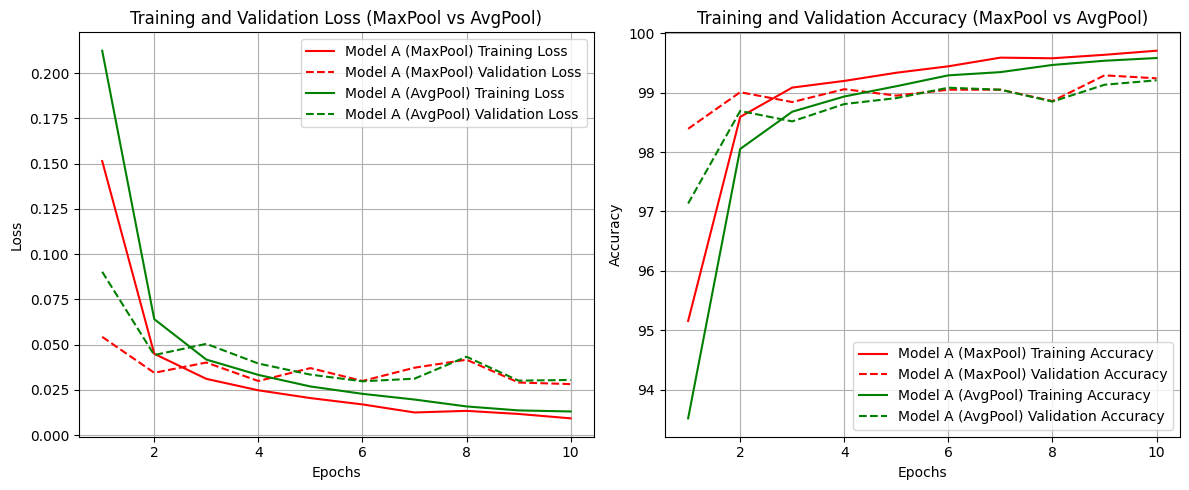

In [ ]:
epochs = range(1, num_epochs + 1)

# Plot Training & Validation Loss
fig2 = plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_a, 'r', label='Model A (MaxPool) Training Loss')
plt.plot(epochs, val_losses_a, 'r--', label='Model A (MaxPool) Validation Loss')
plt.plot(epochs, train_losses_a_avgpool, 'g', label='Model A (AvgPool) Training Loss')
plt.plot(epochs, val_losses_a_avgpool, 'g--', label='Model A (AvgPool) Validation Loss')
plt.title('Training and Validation Loss (MaxPool vs AvgPool)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies_a, 'r', label='Model A (MaxPool) Training Accuracy')
plt.plot(epochs, val_accuracies_a, 'r--', label='Model A (MaxPool) Validation Accuracy')
plt.plot(epochs, train_accuracies_a_avgpool, 'g', label='Model A (AvgPool) Training Accuracy')
plt.plot(epochs, val_accuracies_a_avgpool, 'g--', label='Model A (AvgPool) Validation Accuracy')
plt.title('Training and Validation Accuracy (MaxPool vs AvgPool)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Confusion Matrix (Model A dengan AvgPool)

Visualisasi _confusion matrix_ untuk `ModelA_AvgPool`.

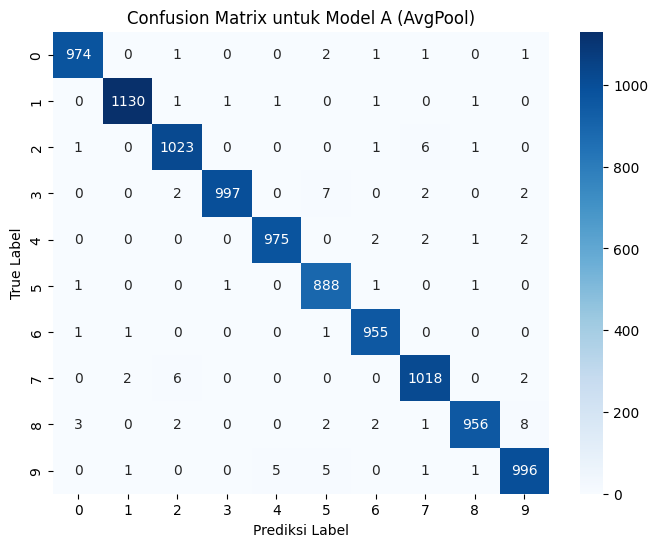

In [ ]:
# Confusion Matrix untuk Model A (AvgPool)
plot_confusion_matrix(labels_a_avgpool, predictions_a_avgpool, classes, 'Model A (AvgPool)')